In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Разведочный анализ данных для hirehi. 

In [3]:
palette = ["#1f2d3a", "#0f766e", "#2a4d69"]

### Работа с исходными данными

In [74]:
data = pd.read_csv('vacancys_final.csv')
data.sample(3)

,Unnamed: 0,id,title,category,company,format,level,salary,link,skills
7094,7094,27964,data analyst,analytics,NDA,офис Узбекистан,middle,~ от 136 200 ₽,https://hirehi.ru/analytics/data-analyst-27964,"['sql', 'аналитическое мышление', 'английский'..."
1820,1820,34797,QA Engineer (manual),qa,Авито,удалённо,intern,~ от 60 800 ₽,https://hirehi.ru/qa/qa-engineer-manual-34797,"['python', 'java', 'go', 'javascript', 'sql', ..."
4173,4173,32066,product owner,management,NDA,офис Алматы,middle,~ от 194 600 ₽,https://hirehi.ru/management/product-owner-32066,"['product owner', 'финтех', 'интернет-банкинг'..."


Оценим, как распределено количество требуемых инструментов для различных вакансий. Для этого создадим дополнительный признак - `skills_num`.

In [5]:
def get_len(x):
    if x == '[]':
        return 0
    return len(x[1:-2].split(', '))

In [6]:
data['skills_num'] = data['skills'].apply(lambda x: get_len(x))
skills_length_grouped = data['skills_num'].value_counts()
skills_length_grouped

skills_num
10    1353
15    1199
12    1198
14    1193
13     981
11     959
9      443
8      347
7      246
16     238
6      176
5      112
4       65
17      61
0       55
20      39
18      29
3       27
19      18
2       11
1        4
Name: count, dtype: int64

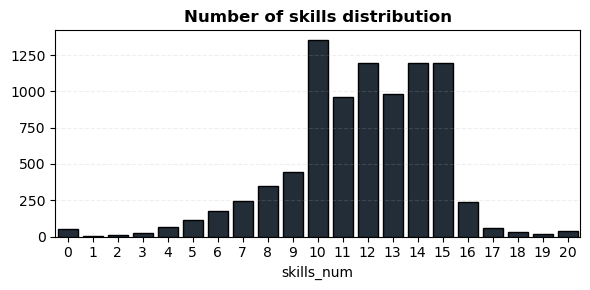

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(
    x=skills_length_grouped.index,
    y=skills_length_grouped.values,
    color=palette[0],
    edgecolor='black'
)
ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.set_title('Number of skills distribution', fontweight='bold')
plt.tight_layout()

Большинство вакансий требуют от 10 до 15 навыков. При этом наблюдается небольшое число вакансий, для которых навыки не требуются - скорее всего карточка не заполнена

Посмотрим на распределение количества необходимых навыков относительно различных направлений:

In [8]:
data_grouped = data.groupby('category')['skills_num'].mean()
data_grouped

category
analytics      11.633962
design         10.543161
development    11.922481
devops         13.572148
management     11.214158
marketing      10.518265
qa             12.278993
Name: skills_num, dtype: float64

Посмотрим на зависимость количества скиллов от грейда специалиста:

In [58]:
level_groupped = data.groupby('level')['skills_num'].mean()
level_groupped

level
head          11.333333
intern         9.232558
junior         9.871795
lead          11.945312
middle        11.591027
senior        12.317902
грейда нет     6.000000
не указан      9.000000
Name: skills_num, dtype: float64

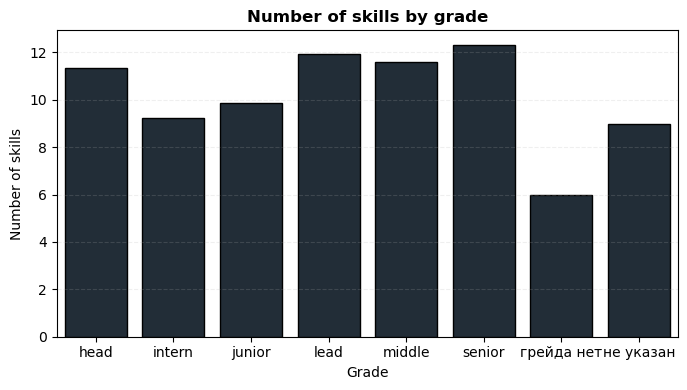

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=level_groupped, 
    color=palette[0],
    edgecolor='black'
)

ax.set_xlabel('Grade')
ax.set_ylabel('Number of skills')
ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.set_title('Number of skills by grade', fontweight='bold')
plt.tight_layout()

Посмотрим, какие навыки требуются в самых распространенных вакансиях:

In [ ]:
top_3_vac = data_processed['title'].value_counts().iloc[1:4].index

title
product manager       225
системный аналитик    211
project manager       208
Name: count, dtype: int64

In [ ]:
top_3_vac = data_processed['title'].value_counts().iloc[1:4].index
print(f'Топ 3 вакансий: {top_3_vac}')

Топ 3 вакансий: Index(['product manager', 'системный аналитик', 'project manager'], dtype='object', name='title')


'product manager'

In [174]:
top_n = 5

skill_title = pd.merge( 
    left=data_processed, 
    right=data_skills, 
    on='id' 
)[['title', 'skill']] 
top3_exp = skill_title[skill_title['title'].isin(top_3_vac)] 
top3_exp = top3_exp.groupby(['title', 'skill']).size().reset_index(name='skills_num')
top3_exp = top3_exp.sort_values(['title', 'skills_num'], ascending=False)

data_skills_top3 = []
data_skills_top3.append(top3_exp[top3_exp['title'] == 'product manager'].head(top_n))
data_skills_top3.append(top3_exp[top3_exp['title'] == 'системный аналитик'].head(top_n))
data_skills_top3.append(top3_exp[top3_exp['title'] == 'project manager'].head(top_n))
data_skills_top3

[               title               skill  skills_num
 421  product manager  product management         107
 480  product manager             roadmap          50
 422  product manager     product manager          45
 637  product manager           аналитика          44
 27   product manager                  ai          42,
                    title       skill  skills_num
 1818  системный аналитик        bpmn         109
 2071  системный аналитик         sql         105
 2105  системный аналитик         uml          95
 2034  системный аналитик        rest          68
 1840  системный аналитик  confluence          61,
                 title                 skill  skills_num
 1282  project manager    project management         101
 952   project manager                 agile          65
 1172  project manager                  jira          57
 1334  project manager                 scrum          48
 1742  project manager  управление проектами          39]

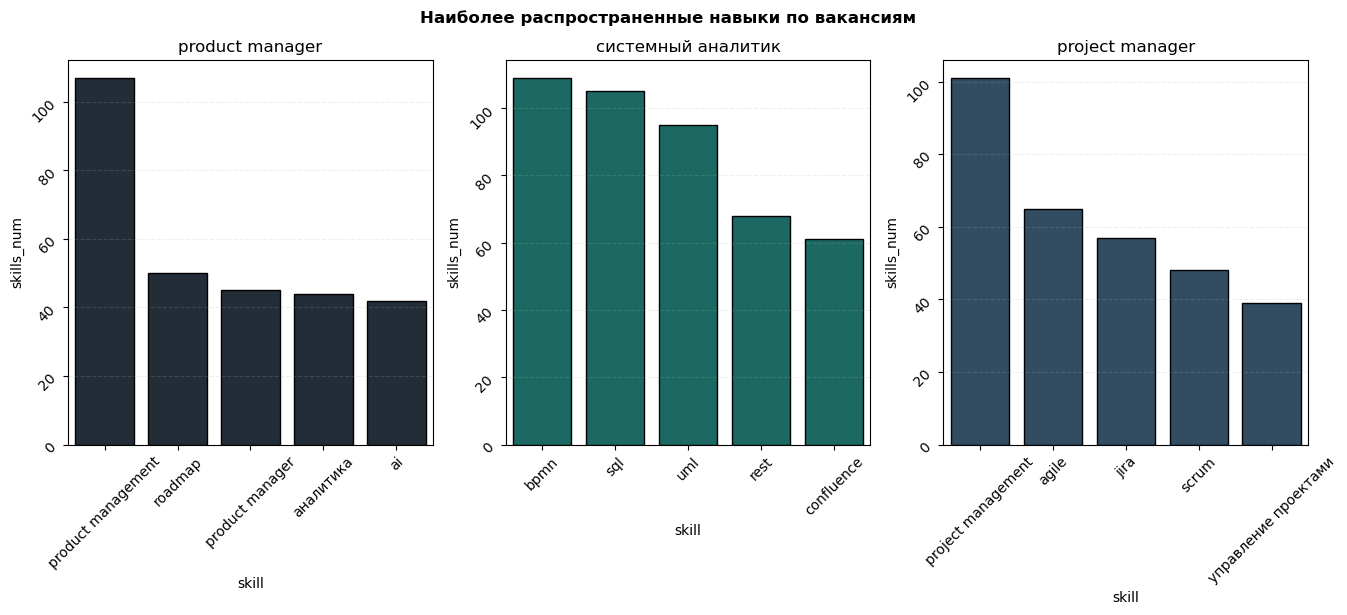

In [195]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))
fig.suptitle('Наиболее распространенные навыки по вакансиям', fontweight='bold')
for i in range(3):
    sns.barplot(
        data=data_skills_top3[i],
        x='skill',
        y='skills_num',
        color=palette[i],
        edgecolor='black',
        ax=axes[i]
    )
    axes[i].grid(axis='y', linestyle='--', alpha=0.2)
    axes[i].set_title(top_3_vac[i])
    axes[i].tick_params(labelrotation=45)

Использован метод [`tick_params`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.tick_params.html) из библиотеки matplotlib. Необзодимость обусловлена использование объектно ориентированного подхода при оформлении графиков.

### Работа с расширенными данными

In [173]:
data_skills = pd.read_csv('skills.csv')

In [10]:
data_skills.isna().sum()

id        0
skill    55
dtype: int64

Количество пропущенных не поменялось, поэтому удалим их из рассмотрения

In [11]:
data_skills = data_skills.dropna()

Дубликаты и кардинальность: 

In [12]:
print(f'Наличе дубликатов:              {data_skills.duplicated().any()}')
print(f'Количество уникальных значений: {data_skills['skill'].nunique()}')

Наличе дубликатов:              False
Количество уникальных значений: 10409


Определим самые часто-встречающиеся навыки:

In [232]:
top_n = 15
skill_stats = data_skills['skill'].value_counts().head(top_n).sort_values()
skill_stats

skill
ai             696
redis          701
аналитика      729
jira           753
typescript     797
linux          850
ci/cd          921
api           1048
kafka         1072
kubernetes    1170
git           1291
docker        1512
postgresql    1519
python        2091
sql           2289
Name: count, dtype: int64

#### Сделать на основе зп

Либо учитывать зарплату, либо просто добавить средние зп по представленным скиллам

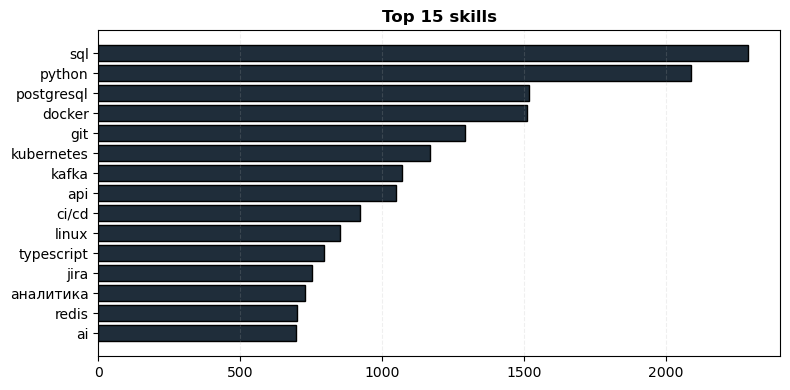

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    y=skill_stats.index,
    width=skill_stats.values,
    edgecolor='black',
    color=palette[0]
)

ax.grid(axis='x', linestyle='--', alpha=0.2)
ax.set_title(f'Top {top_n} skills', fontweight='bold')
plt.tight_layout()

#### Работа с обработанных исходником

In [15]:
data_processed = pd.read_csv('analysys.csv')
data_processed

,id,title,category,company,level,salary,link,format,city/country
0,36700,quality assurance (manual),qa,NDA,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,удалённо,Не указано
2,36697,platform engineer,devops,NDA,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,удалённо,Не указано
3,36696,growth marketing manager,marketing,NDA,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,удалённо,Не указано
4,36695,Бизнес аналитик,analytics,ВТБ,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,гибрид,Москва
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,middle,200000,https://hirehi.ru/development/ml-engineer-24856,удалённо,Не указано
8750,24838,Разработчик PHP,development,Системы документооборота,senior,150000,https://hirehi.ru/development/razrabotchik-php...,офис,Казань
8751,24836,Проектный менеджер IT,management,Системы документооборота,junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,удалённо,РФ


Попробуем понять, за какой навык платят наибольшую зарплату. Так как в списке навыков есть редко встречающиеся и слабо интерпретируемые навыки, рассмотрим топ 600 самых распространенных навыков:  

In [226]:
top_skills = data_skills['skill'].value_counts().head(600).index
top_skills

Index(['sql', 'python', 'postgresql', 'docker', 'git', 'kubernetes', 'kafka',
       'api', 'ci/cd', 'linux',
       ...
       'digital marketing', 'виртуализация', 'отчётность', 'stripe',
       'банковские продукты', 'макеты', 'логирование', 'ruby on',
       'распределённые системы', 'антифрод'],
      dtype='object', name='skill', length=600)

In [228]:
top_exp = data_skills[data_skills['skill'].isin(top_skills)]
top_exp

,id,skill
0,36700,qa
1,36700,manual testing
3,36700,api
4,36700,sdlc
7,36700,web testing
...,...,...
102902,24786,prometheus
102903,24786,docker
102904,24786,kubernetes
102905,24786,nginx


In [280]:
skill_salary = pd.merge(
    left=top_exp,
    right=data_processed,
    on='id'
)[['skill', 'salary']]
skill_salary_grouped = skill_salary.groupby('skill')['salary'].agg(['mean', 'median', 'count'])
skill_salary_grouped = skill_salary_grouped.sort_values(['median', 'mean'], ascending=False)
skill_salary_grouped_top = skill_salary_grouped.head(5)
skill_salary_grouped_top

,mean,median,count
skill,,,
distributed systems,433733.820896,441800.0,67
defi,460690.476190,426400.0,42
leadership,440526.567568,420000.0,37
scalability,449998.406250,417500.0,32
cloud,401100.000000,406650.0,40


<Axes: xlabel='skill'>

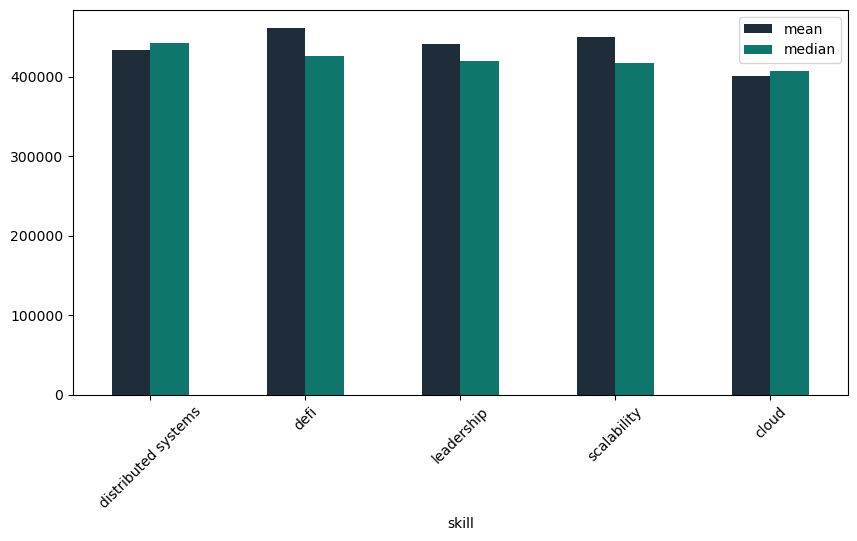

In [285]:
skill_salary_grouped_top[['mean', 'median']].plot(kind='bar', figsize=(10, 5), color=palette, rot=45)

На основе документации [`plot`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).